In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/kittuchikara/test-dataset/arvyax_test_inputs_120.xlsx - Sheet1.csv
/kaggle/input/datasets/kittuchikara/train-data/Sample_arvyax_reflective_dataset.xlsx - Dataset_120.csv


In [2]:
import re
import joblib
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [3]:
train_data=pd.read_csv('/kaggle/input/datasets/kittuchikara/train-data/Sample_arvyax_reflective_dataset.xlsx - Dataset_120.csv')
test_data=pd.read_csv('/kaggle/input/datasets/kittuchikara/test-dataset/arvyax_test_inputs_120.xlsx - Sheet1.csv')

In [4]:
train_data.head()

,id,journal_text,ambience_type,duration_min,sleep_hours,energy_level,stress_level,time_of_day,previous_day_mood,face_emotion_hint,reflection_quality,emotional_state,intensity
0,1,The ocean ambience helped me stop drifting and...,ocean,12,6.5,4,2,afternoon,mixed,calm_face,clear,focused,3
1,2,"I tried to relax during the forest ambience, y...",forest,35,6.0,2,4,evening,calm,tired_face,vague,restless,3
2,3,The forest session slowed my thoughts and I fe...,forest,3,NaN,2,1,night,overwhelmed,happy_face,clear,calm,3
3,4,"the mountain ambience was pleasant, though i c...",mountain,25,7.0,4,4,night,focused,calm_face,vague,neutral,1
4,5,"The rain session gave me a pause, but the pres...",rain,25,5.0,3,5,afternoon,NaN,tense_face,clear,overwhelmed,5


In [6]:
test_data.head()

,id,journal_text,ambience_type,duration_min,sleep_hours,energy_level,stress_level,time_of_day,previous_day_mood,face_emotion_hint,reflection_quality
0,10001,woke up feeling more organized mentally. i was...,cafe,4,8.5,3,1,night,mixed,happy_face,vague
1,10002,started off distracted most of the time. this ...,mountain,4,8.5,1,2,afternoon,mixed,happy_face,clear
2,10003,kinda calm ...,cafe,15,8.5,2,5,evening,calm,happy_face,vague
3,10004,after the session i felt able to think straigh...,ocean,7,7.0,2,3,morning,overwhelmed,none,clear
4,10005,lowkey felt pretty grounded. i had to restart ...,ocean,20,8.5,1,5,afternoon,calm,tired_face,vague


In [7]:
train_data['journal_text'][0]

'The ocean ambience helped me stop drifting and concentrate on my next steps. My to-do list feels less chaotic.'

In [8]:
train_data['emotional_state'].unique()

array(['focused', 'restless', 'calm', 'neutral', 'overwhelmed', 'mixed'],
      dtype=object)

In [9]:
train_data.isnull().sum()

id                      0
journal_text            0
ambience_type           0
duration_min            0
sleep_hours             7
energy_level            0
stress_level            0
time_of_day             0
previous_day_mood      15
face_emotion_hint     123
reflection_quality      0
emotional_state         0
intensity               0
dtype: int64

In [10]:
count=train_data['emotional_state'].value_counts()
count

emotional_state
calm           216
restless       209
neutral        201
focused        193
mixed          191
overwhelmed    190
Name: count, dtype: int64

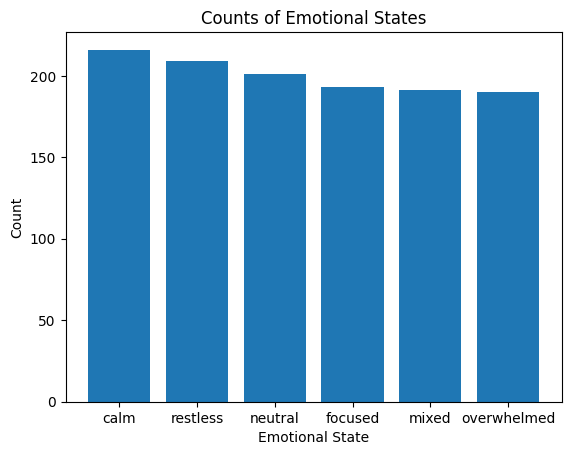

In [11]:
plt.bar(count.index, count.values)
plt.xlabel('Emotional State')
plt.ylabel('Count')
plt.title('Counts of Emotional States')
plt.show()

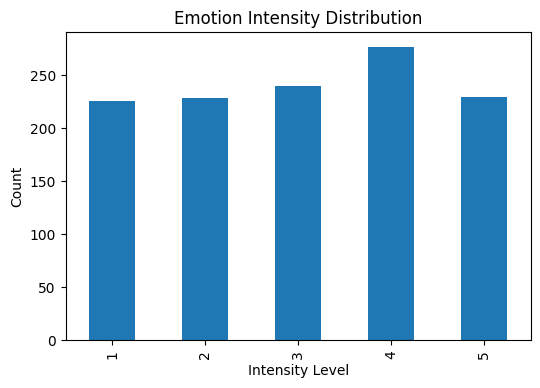

In [12]:
plt.figure(figsize=(6,4))
train_data['intensity'].value_counts().sort_index().plot(kind='bar')

plt.title("Emotion Intensity Distribution")
plt.xlabel("Intensity Level")
plt.ylabel("Count")

plt.show()

In [13]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

In [14]:
train_data["journal_text"] = train_data["journal_text"].apply(clean_text)
test_data["journal_text"] = test_data["journal_text"].apply(clean_text)

In [15]:
print(train_data["journal_text"].iloc[0])
print(test_data["journal_text"].iloc[0])

the ocean ambience helped me stop drifting and concentrate on my next steps my todo list feels less chaotic
woke up feeling more organized mentally i was more tired than i thought


In [16]:
print(train_data.shape)
print(test_data.shape)

(1200, 13)
(120, 11)


In [17]:
tfidf = TfidfVectorizer(
    max_features=3000,
    stop_words="english"
)

In [18]:
X_train_text = tfidf.fit_transform(train_data["journal_text"])

In [19]:
X_test_text = tfidf.transform(test_data["journal_text"])

In [20]:
print(X_train_text.shape)
print(X_test_text.shape)

(1200, 274)
(120, 274)


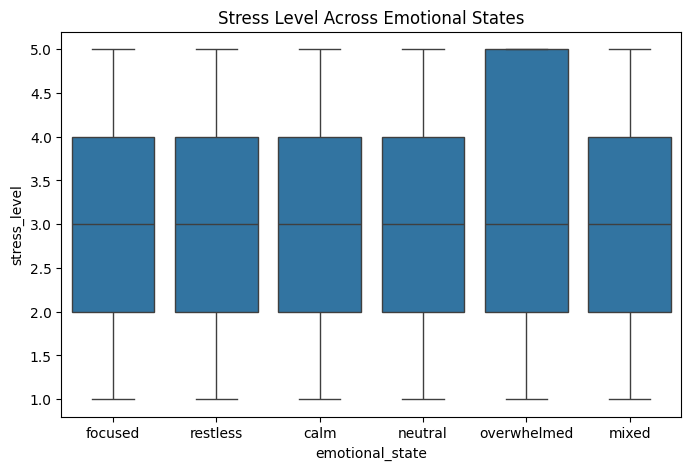

In [21]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(
    x="emotional_state",
    y="stress_level",
    data=train_data)

plt.title("Stress Level Across Emotional States")
plt.show()

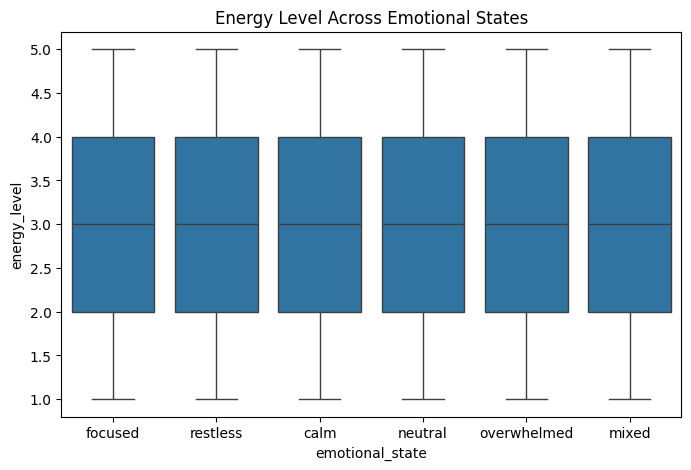

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="emotional_state",
    y="energy_level",
    data=train_data
)

plt.title("Energy Level Across Emotional States")
plt.show()

In [23]:
meta_cols = [
    "ambience_type",
    "duration_min",
    "sleep_hours",
    "energy_level",
    "stress_level",
    "time_of_day",
    "previous_day_mood",
    "face_emotion_hint",
    "reflection_quality"
]


In [24]:
X_train_meta = train_data[meta_cols]
X_test_meta = test_data[meta_cols]

In [25]:
X_train_meta = pd.get_dummies(X_train_meta)
X_test_meta = pd.get_dummies(X_test_meta)


In [26]:
X_train_meta, X_test_meta = X_train_meta.align(X_test_meta, join="left", axis=1, fill_value=0)

In [27]:
print(X_train_meta.shape)
print(X_test_meta.shape)

(1200, 29)
(120, 29)


In [28]:
X_train_meta = X_train_meta.values
X_test_meta = X_test_meta.values

In [29]:
X_train_meta = X_train_meta.astype(float)
X_test_meta = X_test_meta.astype(float)

In [30]:
from scipy.sparse import hstack
X_train = hstack([X_train_text, X_train_meta])
X_test = hstack([X_test_text, X_test_meta])

In [31]:
print(X_train.shape)
print(X_test.shape)

(1200, 303)
(120, 303)


In [32]:
state_encoder = LabelEncoder()
y_state = state_encoder.fit_transform(train_data["emotional_state"])

In [33]:
dict(zip(state_encoder.classes_, range(len(state_encoder.classes_))))

{'calm': 0,
 'focused': 1,
 'mixed': 2,
 'neutral': 3,
 'overwhelmed': 4,
 'restless': 5}

In [34]:
y_intensity = train_data["intensity"]

In [35]:
X_train = X_train.toarray()
X_test = X_test.toarray()

X_train = np.nan_to_num(X_train)
X_test = np.nan_to_num(X_test)

## Emotion prediction

In [36]:
state_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

state_model.fit(X_train, y_state)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

In [37]:
state_pred = state_model.predict(X_test)

In [38]:
state_pred_labels = state_encoder.inverse_transform(state_pred)

In [39]:
state_pred_labels[:10]

array(['focused', 'restless', 'focused', 'focused', 'calm', 'mixed',
       'restless', 'overwhelmed', 'restless', 'overwhelmed'], dtype=object)

## Intensity prediction

In [40]:
intensity_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

intensity_model.fit(X_train, y_intensity)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

In [41]:
intensity_pred = intensity_model.predict(X_test)
intensity_pred[:10]

array([1, 5, 4, 2, 5, 4, 4, 3, 1, 5])

In [42]:
state_probs = state_model.predict_proba(X_test)
state_probs[:10]

array([[0.04333333, 0.6       , 0.02666667, 0.04666667, 0.14      ,
        0.14333333],
       [0.11333333, 0.15666667, 0.15333333, 0.18333333, 0.07666667,
        0.31666667],
       [0.18666667, 0.36      , 0.11666667, 0.04333333, 0.10333333,
        0.19      ],
       [0.05      , 0.89      , 0.02      , 0.02      , 0.01      ,
        0.01      ],
       [0.30666667, 0.06      , 0.08      , 0.29666667, 0.16666667,
        0.09      ],
       [0.14666667, 0.09      , 0.27333333, 0.20333333, 0.20666667,
        0.08      ],
       [0.07666667, 0.11      , 0.11333333, 0.06666667, 0.11      ,
        0.52333333],
       [0.12666667, 0.08333333, 0.11      , 0.13666667, 0.39666667,
        0.14666667],
       [0.03666667, 0.05333333, 0.03666667, 0.02666667, 0.01666667,
        0.83      ],
       [0.11666667, 0.13333333, 0.1       , 0.07      , 0.43333333,
        0.14666667]])

## Confidence + uncertainty

In [43]:
confidence = np.max(state_probs, axis=1)
confidence[:10]

array([0.6       , 0.31666667, 0.36      , 0.89      , 0.30666667,
       0.27333333, 0.52333333, 0.39666667, 0.83      , 0.43333333])

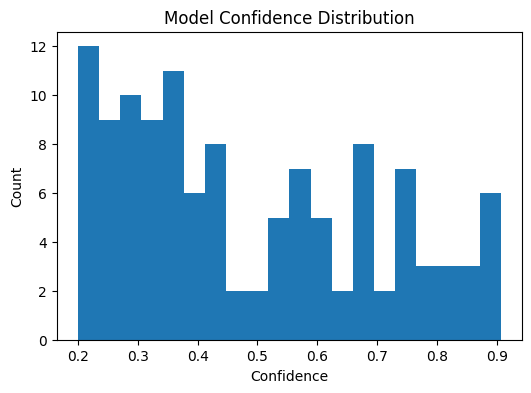

In [44]:
plt.figure(figsize=(6,4))

plt.hist(confidence, bins=20)

plt.title("Model Confidence Distribution")
plt.xlabel("Confidence")
plt.ylabel("Count")

plt.show()

In [45]:
uncertain_flag = (confidence < 0.60).astype(int)

uncertain_flag[:10]

array([0, 1, 1, 0, 1, 1, 1, 1, 0, 1])

In [46]:
stress = test_data["stress_level"].values
energy = test_data["energy_level"].values
time_of_day = test_data["time_of_day"].values

## Decision engine

In [47]:
def decide_action(state, intensity, stress, energy, time):

    if stress >= 7:
        return "box_breathing", "now"

    if state == "overwhelmed":
        return "grounding", "within_15_min"

    if state == "restless":
        return "movement", "now"

    if state == "calm" and energy >= 7:
        return "deep_work", "within_15_min"

    if energy <= 3:
        return "rest", "later_today"

    if time == "night":
        return "light_planning", "tomorrow_morning"

    return "journaling", "later_today"

In [48]:
actions = []
times = []

for i in range(len(state_pred_labels)):
    
    action, timing = decide_action(
        state_pred_labels[i],
        intensity_pred[i],
        stress[i],
        energy[i],
        time_of_day[i]
    )
    
    actions.append(action)
    times.append(timing)

In [49]:
print(actions[:10])
print(times[:10])

['rest', 'movement', 'rest', 'rest', 'rest', 'journaling', 'movement', 'grounding', 'movement', 'grounding']
['later_today', 'now', 'later_today', 'later_today', 'later_today', 'later_today', 'now', 'within_15_min', 'now', 'within_15_min']


In [50]:
predictions = pd.DataFrame({
    
    "id": test_data["id"],
    
    "predicted_state": state_pred_labels,
    
    "predicted_intensity": intensity_pred,
    
    "confidence": confidence,
    
    "uncertain_flag": uncertain_flag,
    
    "what_to_do": actions,
    
    "when_to_do": times
})

In [51]:
predictions.head()

,id,predicted_state,predicted_intensity,confidence,uncertain_flag,what_to_do,when_to_do
0,10001,focused,1,0.600000,0,rest,later_today
1,10002,restless,5,0.316667,1,movement,now
2,10003,focused,4,0.360000,1,rest,later_today
3,10004,focused,2,0.890000,0,rest,later_today
4,10005,calm,5,0.306667,1,rest,later_today


## predictions.csv

In [52]:
predictions.to_csv("predictions.csv", index=False)

## Feature Understanding

In [53]:
importances = state_model.feature_importances_

In [54]:
text_features = tfidf.get_feature_names_out()
meta_features = X_train_meta_columns = list(pd.get_dummies(train_data[
[
"ambience_type",
"duration_min",
"sleep_hours",
"energy_level",
"stress_level",
"time_of_day",
"previous_day_mood",
"face_emotion_hint",
"reflection_quality"
]]).columns)

feature_names = list(text_features) + meta_features

In [55]:
feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

feat_imp = feat_imp.sort_values("importance", ascending=False)

feat_imp.head(15)

,feature,importance
274,duration_min,0.028741
275,sleep_hours,0.025352
277,stress_level,0.022538
276,energy_level,0.022499
74,felt,0.017376
117,lighter,0.014604
27,calmer,0.014395
179,quiet,0.013343
232,tasks,0.013112
53,drained,0.012295


## Ablation study

In [56]:
from sklearn.model_selection import train_test_split

X_train_t, X_val_t, y_train_t, y_val_t = train_test_split(
    X_train_text,
    y_state,
    test_size=0.2,
    random_state=42
)

In [57]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model_text = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

model_text.fit(X_train_t, y_train_t)

pred_text = model_text.predict(X_val_t)

accuracy_text = accuracy_score(y_val_t, pred_text)

accuracy_text

0.6583333333333333

In [58]:
X_train_full, X_val_full, y_train_full, y_val_full = train_test_split(
    X_train,
    y_state,
    test_size=0.2,
    random_state=42
)

model_full = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

model_full.fit(X_train_full, y_train_full)

pred_full = model_full.predict(X_val_full)

accuracy_full = accuracy_score(y_val_full, pred_full)

accuracy_full

0.65

In [59]:
print("Text-only model accuracy:", accuracy_text)
print("Text + metadata accuracy:", accuracy_full)

Text-only model accuracy: 0.6583333333333333
Text + metadata accuracy: 0.65


## Ablation Study

To understand the contribution of contextual metadata, two models were evaluated:

Text-only model using TF-IDF features from journal reflections.
Text + metadata model combining TF-IDF with contextual signals such as sleep hours, stress level, and energy level.

## Interpretation

The text-only model slightly outperformed the combined model.
This suggests that user reflections already contain strong emotional signals, and the metadata features may introduce noise or weak correlations in some cases.

However, metadata remains valuable for the decision engine, where contextual signals such as stress level and energy level guide action recommendations.

## Error analysis

In [60]:
errors = pd.DataFrame({
    "true_state": y_val_full,
    "pred_state": pred_full
})

errors = errors[errors["true_state"] != errors["pred_state"]]

errors.head(10)

,true_state,pred_state
16,0,4
17,2,4
18,1,5
20,0,5
21,1,2
22,3,0
24,1,2
26,0,5
27,2,3
29,4,5


In [61]:
error_cases = train_data.loc[errors.index, ["journal_text", "emotional_state"]]

error_cases.head(10)

,journal_text,emotional_state
16,the forest session made me calmer but part of ...,mixed
17,the mountain session gave me a pause but the p...,overwhelmed
18,i feel mentally clear after the mountain sessi...,focused
20,the mountain session made me calmer but part o...,mixed
21,the cafe session wasnt enough today everything...,overwhelmed
22,even after the forest track i feel exhausted a...,overwhelmed
24,even after the mountain track i feel exhausted...,overwhelmed
26,i started scattered but the cafe session helpe...,focused
27,the cafe ambience helped me breathe slower and...,calm
29,i wasnt expecting much but the rain session ma...,calm
